In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [32]:
def compare_datasets(true_df, pred_df):
    """
    Compare two discrete {0, 1} datasets using statistical tests.

    Parameters:
    true_df (pd.DataFrame): The true dataset. first columns is text, then there are 28 columns of discrete values {0, 1} indicating whether i-th class is present.
    pred_df (pd.DataFrame): The predicted dataset. first columns is text, then there are 28 columns of discrete values {0, 1} indicating whether i-th class is predicted.

    Returns:
    - heatmap of the confusion matrix with matplotlib
    - heatmap of the correlation matrix with matplotlib
    - recall, precision, f1-score, support for each class
    """

    # Ensure the datasets have the same shape and columns
    assert true_df.shape == pred_df.shape, "Datasets must have the same shape"

    # convert to int the lables in case they are floats
    true_df.iloc[:, 1:] = round(true_df.iloc[:, 1:]).astype(int)
    pred_df.iloc[:, 1:] = pred_df.iloc[:, 1:].round().astype(int)

    # Extract the discrete values (assuming the first column is text)
    true_values = true_df.iloc[:, 1:].values
    pred_values = pred_df.iloc[:, 1:].values

    # Initialize lists to store metrics for each class
    recall_list = []
    precision_list = []
    f1_score_list = []
    support_list = []

    # Calculate metrics for each class
    for i in range(true_values.shape[1]):
        true_class = true_values[:, i]
        pred_class = pred_values[:, i]

        # Calculate confusion matrix components
        TP = ((true_class == 1) & (pred_class == 1)).sum()
        TN = ((true_class == 0) & (pred_class == 0)).sum()
        FP = ((true_class == 0) & (pred_class == 1)).sum()
        FN = ((true_class == 1) & (pred_class == 0)).sum()

        # Calculate precision, recall, f1-score, and support
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        support = TP + FN

        # Append metrics to lists
        precision_list.append(precision)
        recall_list.append(recall)
        f1_score_list.append(f1_score)
        support_list.append(support)

    # Create a DataFrame for the metrics
    metrics_df = pd.DataFrame({
        'Class': true_df.columns[1:],
        'Precision': precision_list,
        'Recall': recall_list,
        'F1-Score': f1_score_list,
        'Support': support_list
    })

    print(metrics_df)

    # Plot confusion matrix heatmap
    confusion_matrix = pd.crosstab(true_values.flatten(), pred_values.flatten())
    plt.figure(figsize=(10, 7))
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix Heatmap')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Plot correlation matrix heatmap
    correlation_matrix = abs(pd.DataFrame(pred_values).corr())
    plt.figure(figsize=(10, 7))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
    plt.title('Correlation Matrix Heatmap')
    plt.xticks(range(len(true_df.columns[1:])), true_df.columns[1:], rotation=45)
    plt.yticks(range(len(true_df.columns[1:])), true_df.columns[1:], rotation=0)
    plt.xlabel('Predicted Classes')
    plt.ylabel('True Classes')
    plt.show()


    # frequency of each class in the true dataset
    class_frequency = true_df.iloc[:, 1:].sum()
    print("-"*50)
    print("Class Frequency in True Dataset:")
    print(class_frequency)

    # frequency of each class in the predicted dataset
    class_frequency = pred_df.iloc[:, 1:].sum()
    print("-"*50)
    print("Class Frequency in Predicted Dataset:")
    print(class_frequency)

    # assign to each text a loss value computed with binary cross-entropy loss weighted by class frequency
    class_weights = 1 / (class_frequency + 1e-6) 
    loss_values = []
    for i in range(true_values.shape[0]):
        true_sample = true_values[i]
        pred_sample = pred_values[i]
        loss = - (class_weights * (true_sample * np.log(pred_sample + 1e-6) + (1 - true_sample) * np.log(1 - pred_sample + 1e-6))).sum()
        loss_values.append(loss)

    true_df['Loss'] = loss_values
    print("-"*50)
    print("Texts with Highest Loss Values:")
    print(true_df.sort_values(by='Loss', ascending=False).head())


  Class  Precision    Recall  F1-Score  Support
0  em_0   0.500000  0.333333  0.400000        3
1  em_1   1.000000  1.000000  1.000000        2
2  em_2   0.666667  1.000000  0.800000        2
3  em_3   1.000000  0.500000  0.666667        2


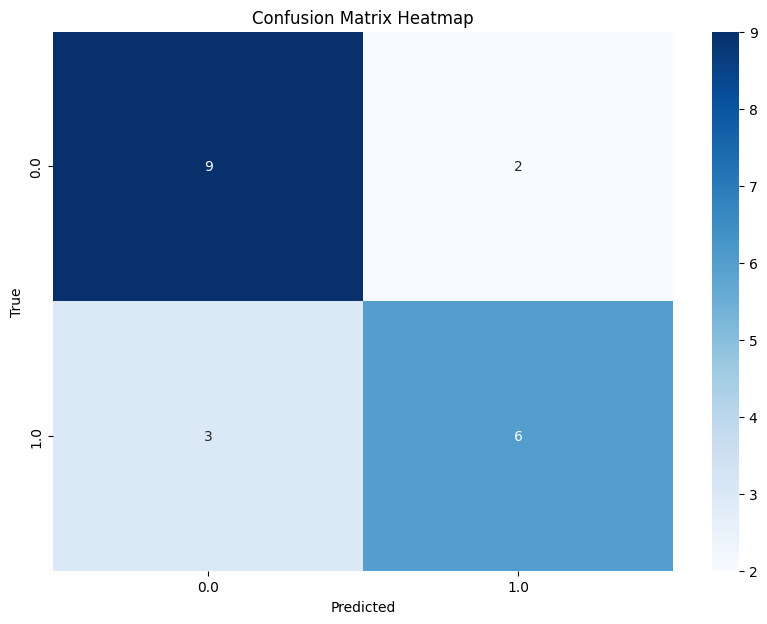

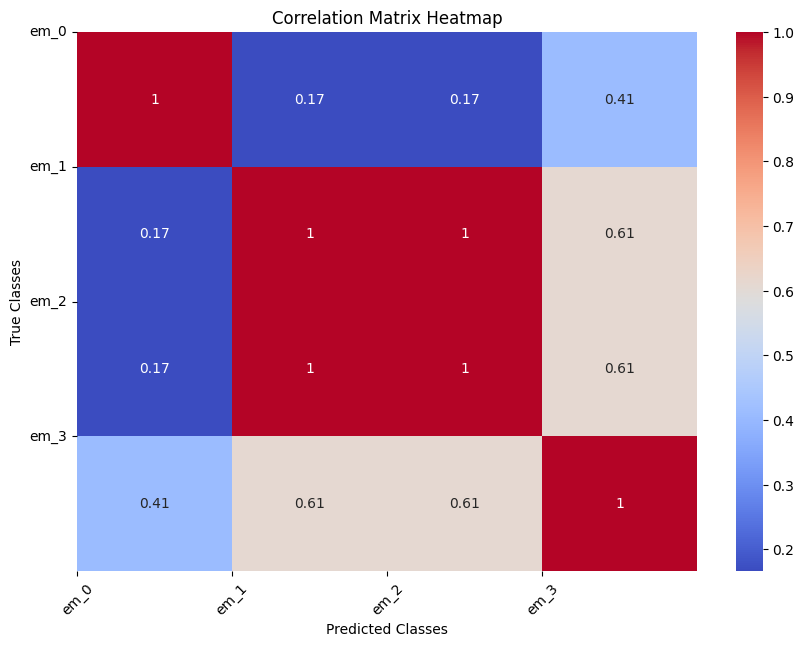

--------------------------------------------------
Class Frequency in True Dataset:
em_0    3.0
em_1    2.0
em_2    2.0
em_3    2.0
dtype: float64
--------------------------------------------------
Class Frequency in Predicted Dataset:
em_0    2.0
em_1    2.0
em_2    3.0
em_3    1.0
dtype: float64
--------------------------------------------------
Texts with Highest Loss Values:
        text  em_0  em_1  em_2  em_3       Loss
3     freddo   0.0     1     0     1  20.723248
2        SVD   1.0     0     0     0  11.512919
4      pasta   1.0     0     1     0   6.907750
0  markovian   1.0     0     1     0  -0.000002
1      bloto   0.0     1     0     1  -0.000002


In [33]:
# mock data for testing
true_data = { 'text': ['markovian', 'bloto', 'SVD', 'freddo', 'pasta'],
              'em_0': [0.8, 0, 1, 0, 1],
                'em_1': [0, 1, 0, 1, 0],
                'em_2': [1, 0, 0, 0, 1], 
                'em_3': [0, 1, 0, 1, 0]}
pred_data = { 'text': ['markovian', 'bloto', 'SVD', 'freddo', 'pasta'],
              'em_0': [1.2, 0, 0, 1, 0],
                'em_1': [0, 1, 0, 1, 0],
                'em_2': [1, 0, 1, 0, 1],
                'em_3': [0, 1, 0, 0, 0]}

true_df = pd.DataFrame(true_data)
pred_df = pd.DataFrame(pred_data)

compare_datasets(true_df, pred_df)